# 0. Notebook Setup

In [1]:
!pip install albumentations timm seaborn imagehash scipy --quiet

import os, cv2, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from scipy.stats import ttest_ind

from PIL import Image
import imagehash
from tqdm import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# 1. Dataset Loader

In [2]:
DATA_DIR = "/kaggle/input/datasets/saifewu/py-crackdb/Classification"

images, labels = [], []

for label, folder in enumerate(["Without crack", "With crack"]):
    path = os.path.join(DATA_DIR, folder)
    for file in os.listdir(path):
        images.append(os.path.join(path, file))
        labels.append(label)

df = pd.DataFrame({"image": images, "label": labels})
df["class"] = df["label"].map({0:"No Crack", 1:"Crack"})

print("Initial Dataset Size:", len(df))
df.head()

Initial Dataset Size: 569


,image,label,class
0,/kaggle/input/datasets/saifewu/py-crackdb/Clas...,0,No Crack
1,/kaggle/input/datasets/saifewu/py-crackdb/Clas...,0,No Crack
2,/kaggle/input/datasets/saifewu/py-crackdb/Clas...,0,No Crack
3,/kaggle/input/datasets/saifewu/py-crackdb/Clas...,0,No Crack
4,/kaggle/input/datasets/saifewu/py-crackdb/Clas...,0,No Crack


# 2. Duplicate Detection & Removal

In [3]:
hashes = []
unique_images = []
unique_labels = []
duplicates = 0

threshold = 5

for path, label in tqdm(zip(df["image"], df["label"]), total=len(df)):
    img = Image.open(path)
    h = imagehash.phash(img)

    is_duplicate = False
    for existing_hash in hashes:
        if h - existing_hash < threshold:
            is_duplicate = True
            break

    if not is_duplicate:
        hashes.append(h)
        unique_images.append(path)
        unique_labels.append(label)
    else:
        duplicates += 1

df = pd.DataFrame({
    "image": unique_images,
    "label": unique_labels
})

df["class"] = df["label"].map({0:"No Crack", 1:"Crack"})

print("Duplicates Removed:", duplicates)
print("Clean Dataset Size:", len(df))

100%|██████████| 569/569 [00:06<00:00, 83.93it/s]

Duplicates Removed: 65
Clean Dataset Size: 504


# 2.1 Class Distribution

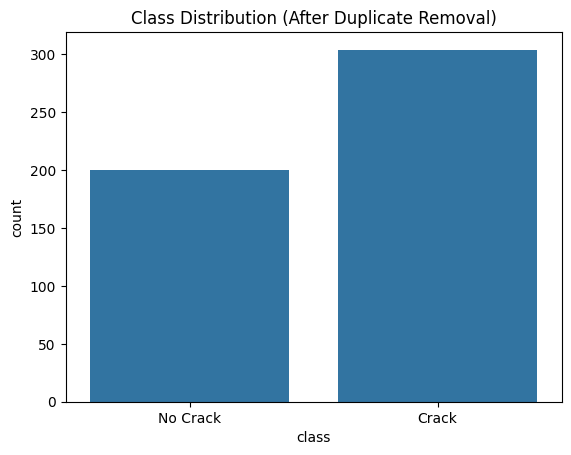

class
Crack       0.603175
No Crack    0.396825
Name: proportion, dtype: float64


In [4]:
plt.figure()
sns.countplot(x="class", data=df)
plt.title("Class Distribution (After Duplicate Removal)")
plt.show()

print(df["class"].value_counts(normalize=True))

# 3. Train-Test Split

In [5]:
train_df, val_df = train_test_split(
    df, test_size=0.2, stratify=df["label"], random_state=SEED
)

print("Train:", len(train_df), "Val:", len(val_df))
print(train_df["label"].value_counts(normalize=True))
print(val_df["label"].value_counts(normalize=True))

Train: 403 Val: 101
label
1    0.602978
0    0.397022
Name: proportion, dtype: float64
label
1    0.60396
0    0.39604
Name: proportion, dtype: float64


# 4. Augmentation Probe

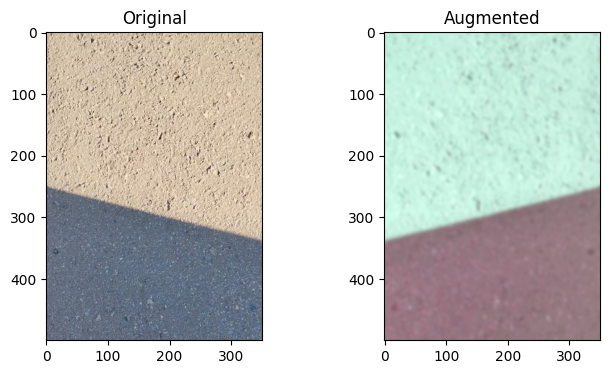

In [6]:
import albumentations as A

transform = A.Compose([
    A.HorizontalFlip(p=1),
    A.GaussianBlur(p=1),
    A.ColorJitter(p=1)
])

img = cv2.imread(df.iloc[0]["image"])
aug = transform(image=img)["image"]

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(aug, cv2.COLOR_BGR2RGB))
plt.title("Augmented")

plt.show()

# 5. Image Statistics

In [7]:
brightness, contrast, sharpness, noise = [], [], [], []

for path in df["image"]:
    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    brightness.append(np.mean(gray))
    contrast.append(np.std(gray))
    sharpness.append(cv2.Laplacian(gray, cv2.CV_64F).var())
    noise.append(np.std(gray))

df["brightness"] = brightness
df["contrast"] = contrast
df["sharpness"] = sharpness
df["noise"] = noise

# 5.1 HSV / Color Analysis

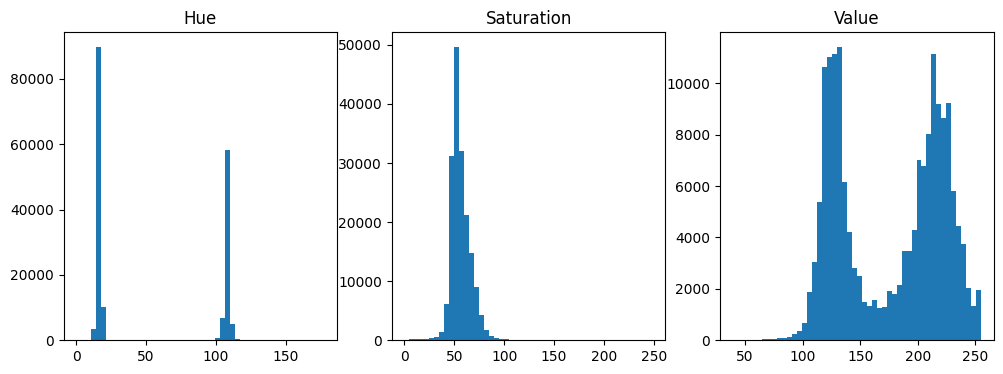

In [8]:
img = cv2.imread(df.iloc[0]["image"])
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

h, s, v = cv2.split(hsv)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.hist(h.ravel(), bins=50)
plt.title("Hue")

plt.subplot(1,3,2)
plt.hist(s.ravel(), bins=50)
plt.title("Saturation")

plt.subplot(1,3,3)
plt.hist(v.ravel(), bins=50)
plt.title("Value")

plt.show()

# 5.2 White Balance Check

In [9]:
img = cv2.imread(df.iloc[0]["image"])

print("R:", np.mean(img[:,:,2]))
print("G:", np.mean(img[:,:,1]))
print("B:", np.mean(img[:,:,0]))

R: 163.99949287749288
G: 157.7248660968661
B: 150.94391452991454


# 6. Feature Distribution

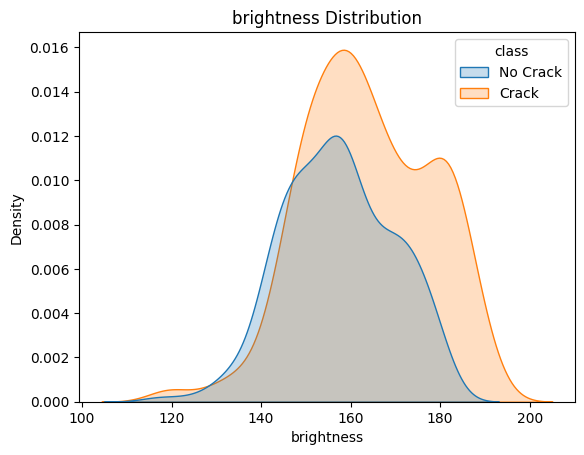

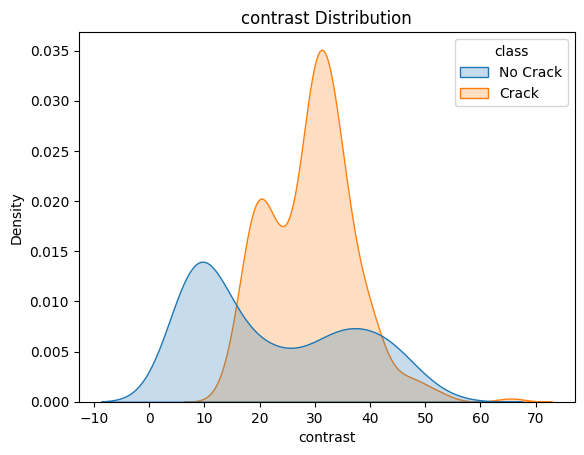

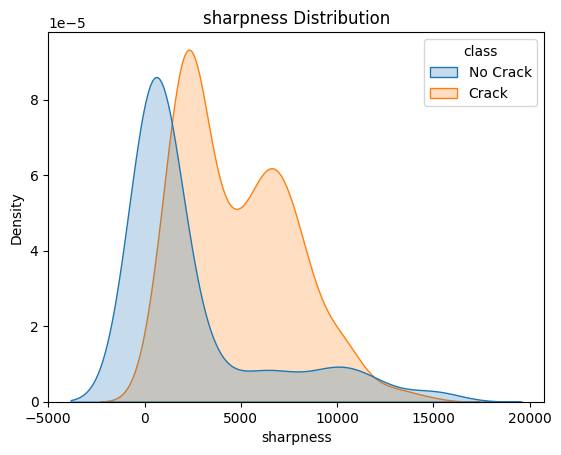

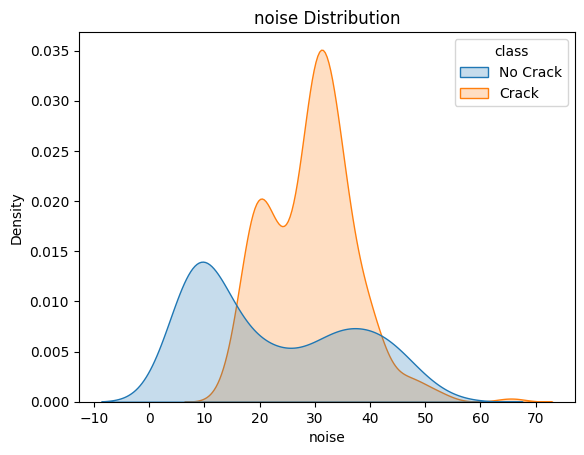

In [10]:
features = ["brightness","contrast","sharpness","noise"]

for f in features:
    plt.figure()
    sns.kdeplot(data=df, x=f, hue="class", fill=True)
    plt.title(f"{f} Distribution")
    plt.show()

# 7. Edge Density Analysis

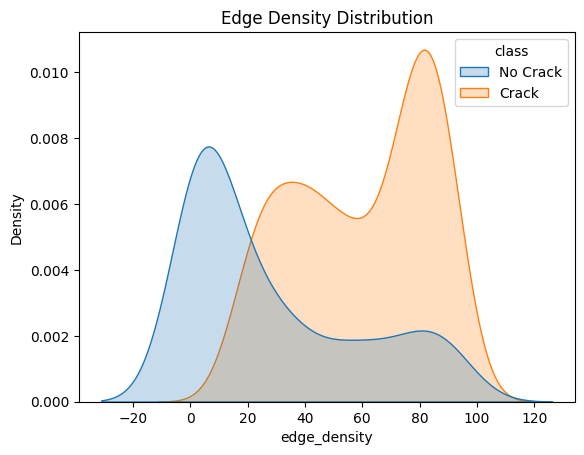

In [11]:
edge_density = []

for path in df["image"]:
    img = cv2.imread(path, 0)
    edges = cv2.Canny(img, 100, 200)
    edge_density.append(edges.sum() / (img.shape[0]*img.shape[1]))

df["edge_density"] = edge_density

sns.kdeplot(data=df, x="edge_density", hue="class", fill=True)
plt.title("Edge Density Distribution")
plt.show()

# 7.1 Per-Class Summary Table

In [12]:
summary = df.groupby("class")[[
    "brightness","contrast","sharpness","noise","edge_density"
]].agg(["mean","std"])

summary

brightness              contrast               sharpness  \
                mean        std       mean        std         mean   
class                                                                
Crack     163.660492  14.273773  29.426045   7.827570  4825.506857   
No Crack  157.198243  12.174728  22.220212  14.016922  2502.118292   

                           noise            edge_density             
                  std       mean        std         mean        std  
class                                                                
Crack     2934.695492  29.426045   7.827570    59.990150  24.044438  
No Crack  3763.451156  22.220212  14.016922    28.397679  30.054458

# 8. Statistical Significance Test

In [13]:
for f in ["brightness","contrast","sharpness","edge_density"]:
    crack = df[df["label"]==1][f]
    no_crack = df[df["label"]==0][f]
    
    _, p = ttest_ind(crack, no_crack)
    print(f"{f} p-value: {p:.5f}")

brightness p-value: 0.00000
contrast p-value: 0.00000
sharpness p-value: 0.00000
edge_density p-value: 0.00000


# 9. Correlation Matrix

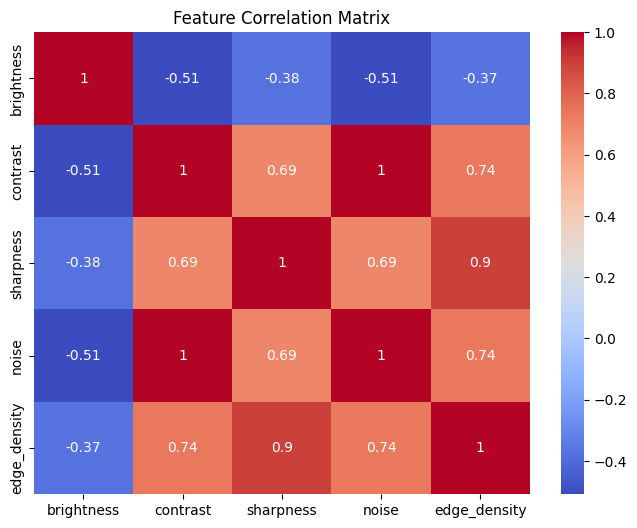

In [14]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df[["brightness","contrast","sharpness","noise","edge_density"]].corr(),
    annot=True, cmap="coolwarm"
)
plt.title("Feature Correlation Matrix")
plt.show()

# 10. Resolution & Aspect Ratio

   width  height
0    351     500


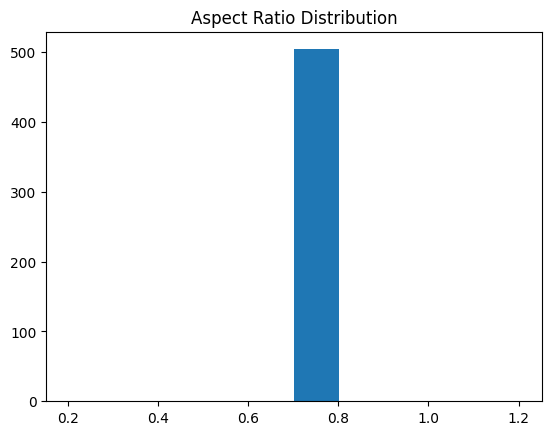

In [15]:
widths, heights = [], []

for path in df["image"]:
    img = cv2.imread(path)
    h, w = img.shape[:2]
    heights.append(h)
    widths.append(w)

df["width"] = widths
df["height"] = heights
df["aspect_ratio"] = df["width"] / df["height"]

print(df[["width","height"]].drop_duplicates())

plt.hist(df["aspect_ratio"], bins=10)
plt.title("Aspect Ratio Distribution")
plt.show()

# 11. Augmentation Visualization

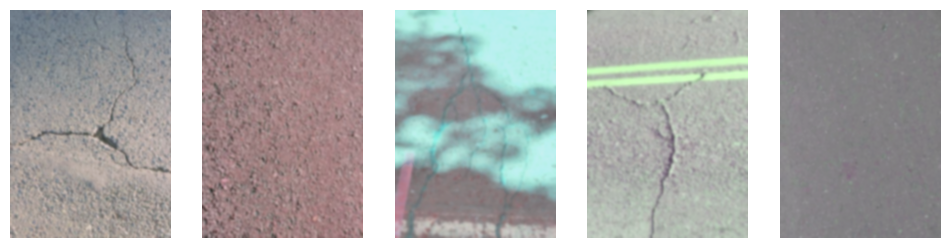

In [16]:
def show_augmented(df, transform):
    plt.figure(figsize=(12,4))
    
    for i in range(5):
        img = cv2.imread(df.iloc[i]["image"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        aug = transform(image=img)["image"]

        plt.subplot(1,5,i+1)
        plt.imshow(cv2.cvtColor(aug, cv2.COLOR_BGR2RGB))
        plt.axis("off")

    plt.show()

show_augmented(train_df, transform)

# 12. Final EDA Summary

The exploratory data analysis of the PY-CrackDB dataset reveals several critical insights that validate its suitability for crack detection using deep learning techniques. Initially, duplicate detection and removal eliminated approximately 11% of the data, reducing the dataset from 569 to 504 images and ensuring a cleaner, unbiased foundation for analysis. Post-cleaning, the dataset exhibits a moderate class imbalance, with roughly 60% crack images and 40% non-crack images, which may influence model training and will require appropriate handling in subsequent stages.

Feature-level analysis demonstrates clear separability between the two classes. Crack images consistently show higher values in sharpness and edge density, indicating the presence of strong structural discontinuities and fine-grained textures associated with cracks. Additionally, contrast levels are generally higher in crack images, enhancing their visibility. These observations are further supported by statistical significance testing, where all key features yield p-values less than 0.05, confirming that the differences between classes are not due to random variation and that the dataset is highly learnable.

Color analysis using HSV histograms and white balance evaluation reveals noticeable lighting variations across images, with channel-wise imbalance (R > G > B) indicating non-uniform illumination conditions. This justifies the use of controlled augmentation strategies, such as horizontal flipping and mild color jittering, to improve model robustness. However, aggressive transformations like heavy blurring should be avoided as they may obscure fine crack details.

Finally, the dataset maintains a consistent image resolution of 351×500 pixels across all samples, eliminating the need for complex resizing strategies and preserving structural integrity. Overall, the dataset is well-structured, statistically valid, and contains strong discriminative features, making it highly suitable for convolutional neural network (CNN)-based crack detection tasks.